Please upload your CSV dataset:


Saving student_marks.csv to student_marks.csv

Dataset uploaded successfully!

========== FIRST 5 ROWS ==========
   Roll No       Name  Subject 1  Subject 2  Subject 3  Subject 4  Attendance
0        1  Student_1        100         62       73.0       92.0          96
1        2  Student_2         72         97       82.0        NaN          78
2        3  Student_3        100         88       71.0       99.0         -94
3        4  Student_4         72         99        NaN       84.0          86
4        5  Student_5         97         70       84.0       70.0          86

========== LAST 5 ROWS ==========
      Roll No          Name  Subject 1  Subject 2  Subject 3  Subject 4  \
996       997   Student_997         88         68       84.0       66.0   
997       998   Student_998         61         96       62.0       84.0   
998       999   Student_999         72         76       90.0       72.0   
999      1000  Student_1000         68         87      100.0       76.0   
1000    

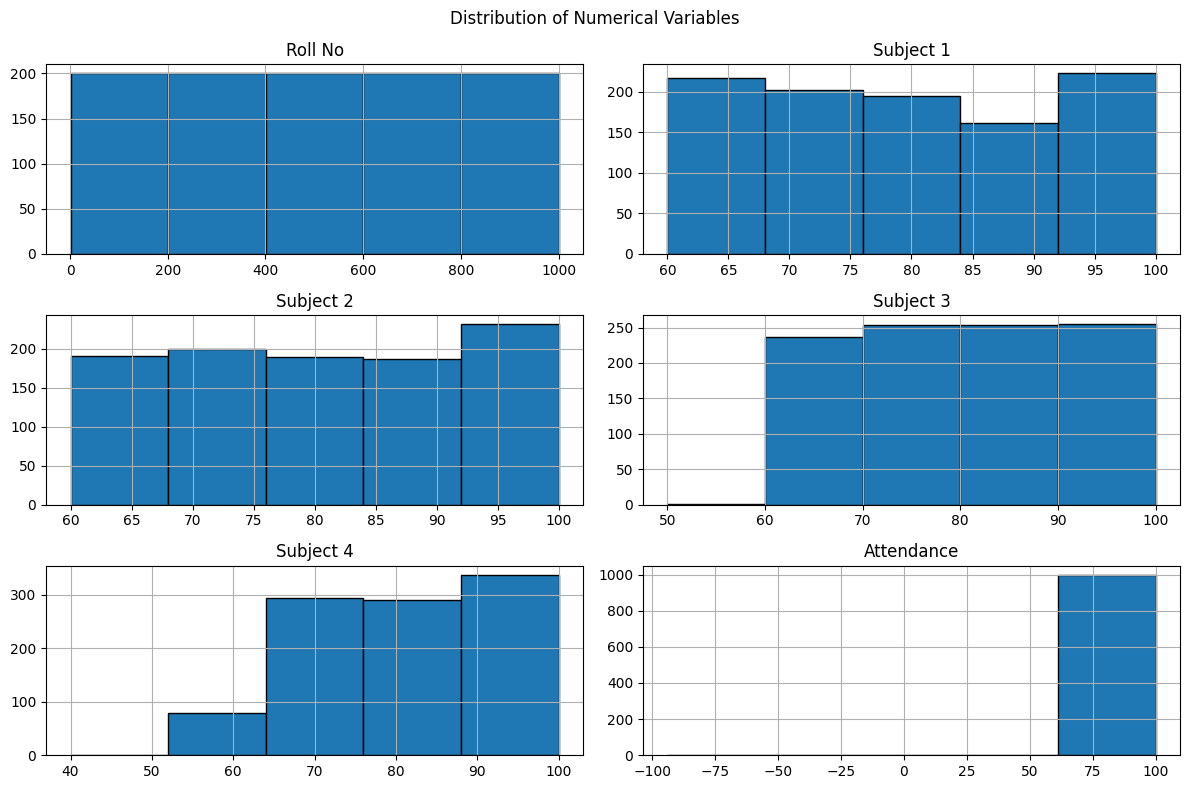

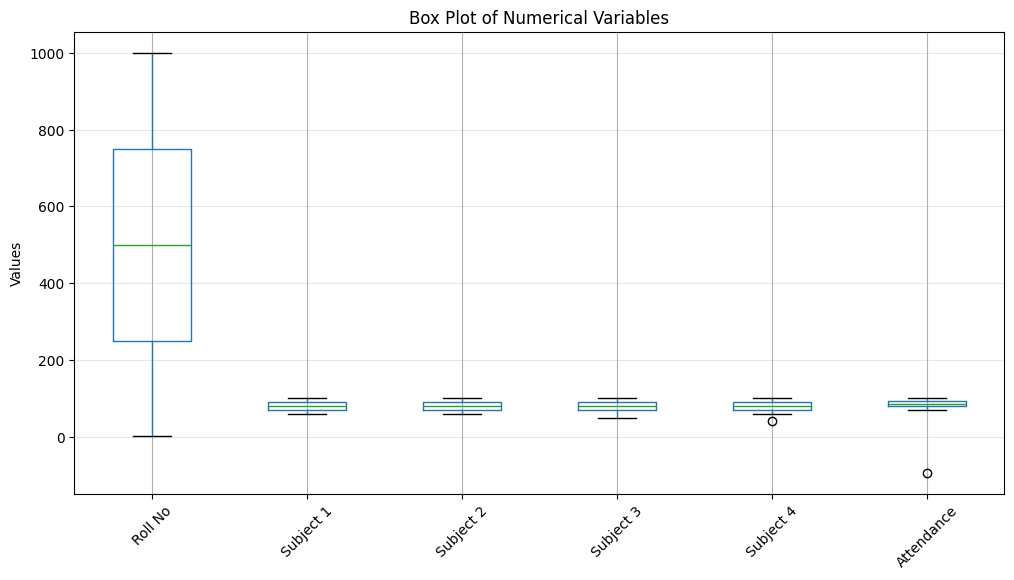


========== CORRELATION MATRIX ==========
             Roll No  Subject 1  Subject 2  Subject 3  Subject 4  Attendance
Roll No     1.000000  -0.057380  -0.009546  -0.043184  -0.010680   -0.026344
Subject 1  -0.057380   1.000000   0.023996  -0.041694  -0.012768    0.005482
Subject 2  -0.009546   0.023996   1.000000  -0.027148   0.003091   -0.021440
Subject 3  -0.043184  -0.041694  -0.027148   1.000000  -0.001717    0.006422
Subject 4  -0.010680  -0.012768   0.003091  -0.001717   1.000000   -0.032187
Attendance -0.026344   0.005482  -0.021440   0.006422  -0.032187    1.000000


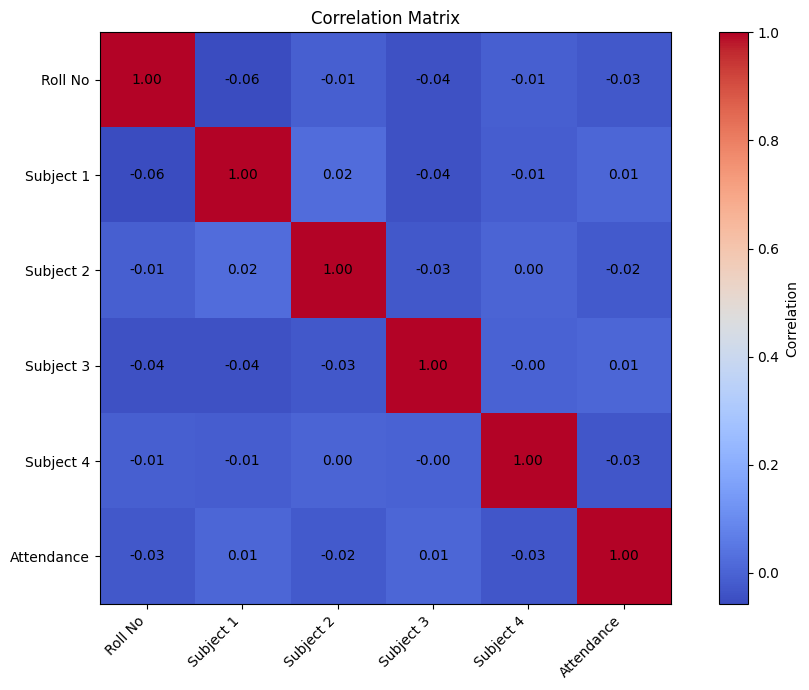


Cleaned dataset saved as: cleaned_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


========== FINAL CLEANED DATASET ==========
     Roll No          Name  Subject 1  Subject 2  Subject 3  Subject 4  \
0          1     Student_1        100         62      73.00     92.000   
1          2     Student_2         72         97      82.00     80.545   
2          3     Student_3        100         88      71.00     99.000   
3          4     Student_4         72         99      79.89     84.000   
4          5     Student_5         97         70      84.00     70.000   
..       ...           ...        ...        ...        ...        ...   
995      996   Student_996         74         89      85.00     71.000   
996      997   Student_997         88         68      84.00     66.000   
997      998   Student_998         61         96      62.00     84.000   
998      999   Student_999         72         76      90.00     72.000   
999     1000  Student_1000         68         87     100.00     76.000   

     Attendance  
0            96  
1            78  
2           

In [1]:
# ============================================================
# DATA LOADING, CLEANING AND EDA
# Using NumPy, Pandas and Matplotlib
# Includes CSV File Upload
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. UPLOAD DATASET
# ------------------------------------------------------------

from google.colab import files

print("Please upload your CSV dataset:")
uploaded = files.upload()

# Get the uploaded filename
filename = list(uploaded.keys())[0]

# Read CSV file
df = pd.read_csv("student_marks.csv")

print("\nDataset uploaded successfully!")
#print("File name:", student_marks.csv)

# ------------------------------------------------------------
# 2. DISPLAY DATASET
# ------------------------------------------------------------

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== LAST 5 ROWS ==========")
print(df.tail())

# ------------------------------------------------------------
# 3. BASIC INFORMATION
# ------------------------------------------------------------

print("\n========== DATASET INFORMATION ==========")
df.info()

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

# ------------------------------------------------------------
# 4. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\n========== MISSING VALUES ==========")

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

# ------------------------------------------------------------
# 5. HANDLE MISSING VALUES
# ------------------------------------------------------------

# Select numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

print("\nNumerical Columns:")
print(numeric_columns.tolist())

# Fill missing numerical values with mean
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].mean())

# Fill missing categorical values with mode
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

# ------------------------------------------------------------
# 6. CHECK DUPLICATE ROWS
# ------------------------------------------------------------

print("\n========== DUPLICATES ==========")

print("Number of duplicate rows:",
      df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)

# ------------------------------------------------------------
# 7. SUMMARY STATISTICS
# ------------------------------------------------------------

print("\n========== SUMMARY STATISTICS ==========")

print(df.describe())

# ------------------------------------------------------------
# 8. MEAN, MEDIAN AND STANDARD DEVIATION
# ------------------------------------------------------------

print("\n========== MEAN ==========")
print(df[numeric_columns].mean())

print("\n========== MEDIAN ==========")
print(df[numeric_columns].median())

print("\n========== STANDARD DEVIATION ==========")
print(df[numeric_columns].std())

print("\n========== MINIMUM ==========")
print(df[numeric_columns].min())

print("\n========== MAXIMUM ==========")
print(df[numeric_columns].max())

# ------------------------------------------------------------
# 9. DISTRIBUTION PLOTS
# ------------------------------------------------------------

# Create histograms for all numerical columns

df[numeric_columns].hist(
    figsize=(12, 8),
    bins=5,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Variables")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. BOXPLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

df[numeric_columns].boxplot()

plt.title("Box Plot of Numerical Variables")
plt.ylabel("Values")
plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 11. SCATTER PLOTS
# ------------------------------------------------------------

# If Study_Hours and Marks exist, create scatter plot

if "Study_Hours" in df.columns and "Marks" in df.columns:

    plt.figure(figsize=(8, 5))

    plt.scatter(
        df["Study_Hours"],
        df["Marks"],
        color="blue",
        s=70
    )

    plt.title("Study Hours vs Marks")
    plt.xlabel("Study Hours")
    plt.ylabel("Marks")
    plt.grid(alpha=0.3)

    plt.show()

# ------------------------------------------------------------
# 12. ATTENDANCE VS MARKS
# ------------------------------------------------------------

if "Attendance" in df.columns and "Marks" in df.columns:

    plt.figure(figsize=(8, 5))

    plt.scatter(
        df["Attendance"],
        df["Marks"],
        color="green",
        s=70
    )

    plt.title("Attendance vs Marks")
    plt.xlabel("Attendance (%)")
    plt.ylabel("Marks")

    plt.grid(alpha=0.3)

    plt.show()

# ------------------------------------------------------------
# 13. CORRELATION MATRIX
# ------------------------------------------------------------

correlation = df[numeric_columns].corr()

print("\n========== CORRELATION MATRIX ==========")
print(correlation)

# ------------------------------------------------------------
# 14. CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.imshow(
    correlation,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

# Add correlation values
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):

        value = correlation.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 15. SAVE CLEANED DATASET
# ------------------------------------------------------------

cleaned_filename = "cleaned_dataset.csv"

df.to_csv(
    cleaned_filename,
    index=False
)

print("\nCleaned dataset saved as:", cleaned_filename)

# ------------------------------------------------------------
# 16. DOWNLOAD CLEANED DATASET
# ------------------------------------------------------------

files.download(cleaned_filename)

print("\n========== FINAL CLEANED DATASET ==========")
print(df)